# Predicción del Abandono de Empleados
## Machine Learning - Ejercicio 5

## Integrantes

| Nombre |
|---|
| Diego Ramirez |
| Liliana Arias |
| Andres Botero |
| Mateo Bolivar |

---

---
## Punto 1 - Descripción del Problema

El objetivo de este ejercicio es construir un modelo predictivo capaz de identificar empleados con alta probabilidad de **abandonar la empresa**, a partir de variables como:

- Nivel de satisfacción laboral
- Última evaluación de desempeño
- Número de proyectos asignados
- Promedio de horas mensuales trabajadas
- Tiempo en la empresa (antigüedad)
- Accidentes laborales
- Promoción en los últimos 5 años
- Departamento y nivel salarial

El problema corresponde a una **clasificación binaria supervisada**:
- `1` → El empleado abandona la empresa
- `0` → El empleado permanece en la empresa

**Dataset:** HR Analytics - Employee Attrition  
**Archivo:** `HR_comma_sep.csv`  
**Observaciones:** 14,999 empleados | 10 variables

## Punto 2 - Importación de librerías

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=PendingDeprecationWarning, module='seaborn')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA

## Punto 3 - Carga de datos

In [2]:
df = pd.read_csv('HR_comma_sep.csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Punto 4 - Exploración de datos (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [5]:
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
# Distribución de la variable objetivo
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='left', data=df, hue='left', legend=False, palette='Set2')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Permanece (0)', 'Abandona (1)'])
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )
plt.title('Distribución de Abandono (left)')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

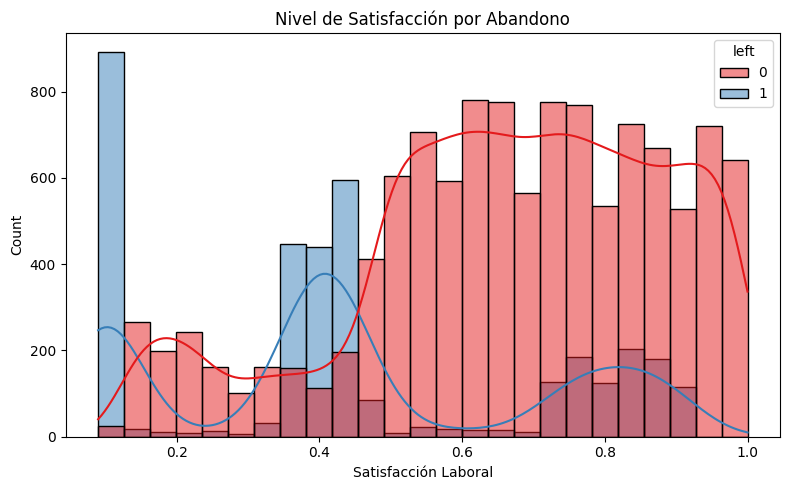

In [7]:
# Satisfacción laboral vs abandono
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='satisfaction_level', hue='left', kde=True, bins=25, palette='Set1')
plt.title('Nivel de Satisfacción por Abandono')
plt.xlabel('Satisfacción Laboral')
plt.tight_layout()
plt.show()

In [ ]:
# Última evaluación y horas mensuales vs abandono
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='left', y='last_evaluation', data=df, hue='left', legend=False, palette='pastel', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Permanece', 'Abandona'])
axes[0].set_title('Última Evaluación vs Abandono')

sns.boxplot(x='left', y='average_montly_hours', data=df, hue='left', legend=False, palette='pastel', ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Permanece', 'Abandona'])
axes[1].set_title('Horas Mensuales vs Abandono')

plt.tight_layout()
plt.show()

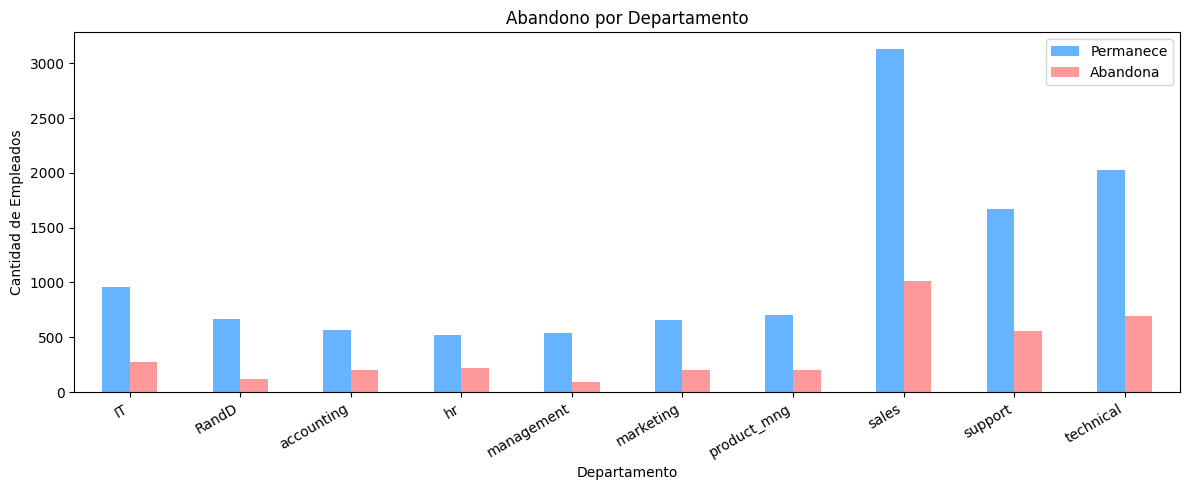

In [9]:
# Abandono por departamento
dept_attrition = df.groupby(['Department', 'left']).size().unstack(fill_value=0)
dept_attrition.plot(kind='bar', color=['#66b3ff', '#ff9999'], figsize=(12, 5))
plt.title('Abandono por Departamento')
plt.xlabel('Departamento')
plt.ylabel('Cantidad de Empleados')
plt.xticks(rotation=30, ha='right')
plt.legend(['Permanece', 'Abandona'])
plt.tight_layout()
plt.show()

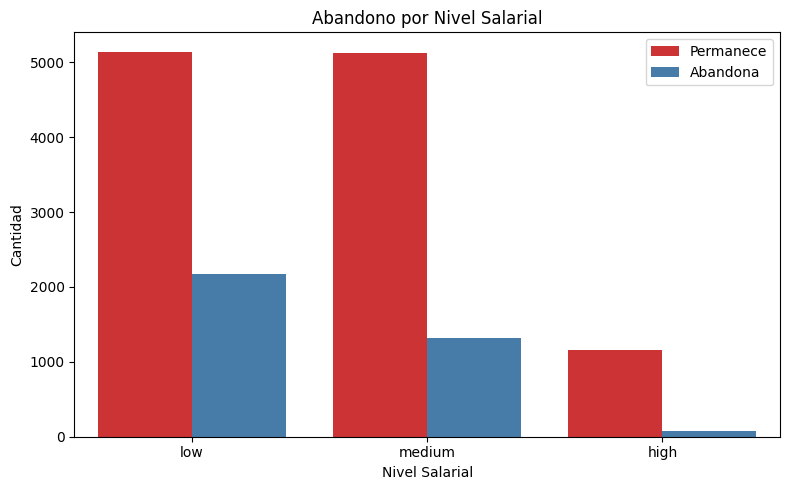

In [10]:
# Abandono por nivel salarial
plt.figure(figsize=(8, 5))
salary_order = ['low', 'medium', 'high']
sns.countplot(x='salary', hue='left', data=df, order=salary_order, palette='Set1')
plt.title('Abandono por Nivel Salarial')
plt.xlabel('Nivel Salarial')
plt.ylabel('Cantidad')
plt.legend(['Permanece', 'Abandona'])
plt.tight_layout()
plt.show()

In [ ]:
# Tiempo en la empresa y proyectos vs abandono
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='left', y='time_spend_company', data=df, hue='left', legend=False, palette='Set2', ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Permanece', 'Abandona'])
axes[0].set_title('Antigüedad en la Empresa vs Abandono')

sns.countplot(x='number_project', hue='left', data=df, palette='Set1', ax=axes[1])
axes[1].set_title('Número de Proyectos vs Abandono')
axes[1].legend(['Permanece', 'Abandona'])

plt.tight_layout()
plt.show()

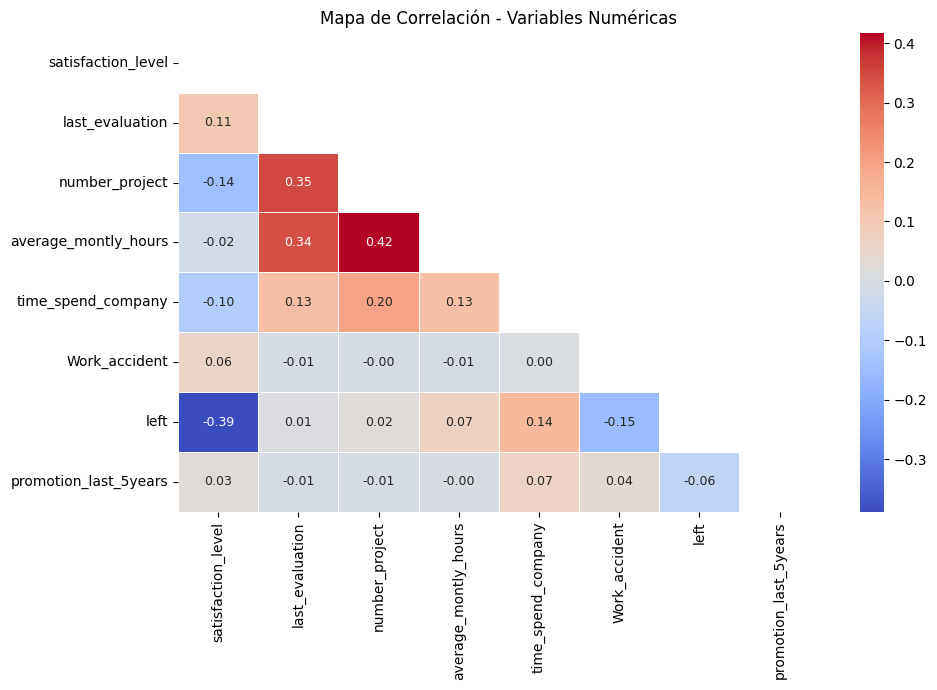

In [12]:
# Mapa de correlación variables numéricas
plt.figure(figsize=(10, 7))
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Mapa de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

## Punto 5 - Preprocesamiento

In [13]:
# La variable objetivo 'left' ya está codificada como 0/1
X = df.drop('left', axis=1)
y = df['left']

print(f'Distribución de clases:\n{y.value_counts()}')
print(f'\nProporción de abandono: {y.mean():.2%}')

Distribución de clases:
left
0    11428
1     3571
Name: count, dtype: int64

Proporción de abandono: 23.81%


In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f'Features numéricas ({len(numeric_features)}): {numeric_features}')
print(f'\nFeatures categóricas ({len(categorical_features)}): {categorical_features}')

In [15]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')
print(f'Clases en train: {dict(y_train.value_counts())}')

Entrenamiento: 11999 muestras
Prueba:        3000 muestras
Clases en train: {0: np.int64(9142), 1: np.int64(2857)}


## Punto 6 - Modelo 1: Regresión Logística

La regresión logística es un modelo lineal interpretable para clasificación binaria. Dado el desbalance de clases (~24% abandono), se usa `class_weight='balanced'` para dar mayor peso a la clase minoritaria.

In [17]:
modelo_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)
prob_lr = modelo_lr.predict_proba(X_test)[:, 1]

In [18]:
print('=== Regresión Logística ===')
print(f'Accuracy:  {accuracy_score(y_test, pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, pred_lr):.4f}')
print(f'Recall:    {recall_score(y_test, pred_lr):.4f}')
print(f'F1-score:  {f1_score(y_test, pred_lr):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, prob_lr):.4f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, pred_lr, target_names=['No abandona', 'Abandona']))

=== Regresión Logística ===
Accuracy:  0.7727
Precision: 0.5143
Recall:    0.8053
F1-score:  0.6277
ROC-AUC:   0.8370

Reporte de Clasificación:
              precision    recall  f1-score   support

 No abandona       0.93      0.76      0.84      2286
    Abandona       0.51      0.81      0.63       714

    accuracy                           0.77      3000
   macro avg       0.72      0.78      0.73      3000
weighted avg       0.83      0.77      0.79      3000



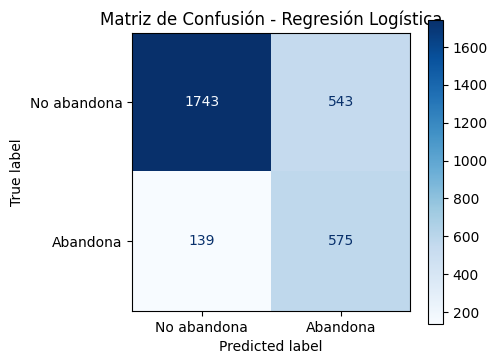

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_lr,
    display_labels=['No abandona', 'Abandona'],
    cmap='Blues', ax=ax
)
plt.title('Matriz de Confusión - Regresión Logística')
plt.tight_layout()
plt.show()

## Punto 7 - Modelo 2: Árbol de Decisión

El árbol de decisión captura relaciones no lineales y genera reglas interpretables. Se limita la profundidad (`max_depth=5`) para evitar sobreajuste.

In [20]:
modelo_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

modelo_dt.fit(X_train, y_train)

pred_dt = modelo_dt.predict(X_test)
prob_dt = modelo_dt.predict_proba(X_test)[:, 1]

In [21]:
print('=== Árbol de Decisión ===')
print(f'Accuracy:  {accuracy_score(y_test, pred_dt):.4f}')
print(f'Precision: {precision_score(y_test, pred_dt):.4f}')
print(f'Recall:    {recall_score(y_test, pred_dt):.4f}')
print(f'F1-score:  {f1_score(y_test, pred_dt):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, prob_dt):.4f}')
print('\nReporte de Clasificación:')
print(classification_report(y_test, pred_dt, target_names=['No abandona', 'Abandona']))

=== Árbol de Decisión ===
Accuracy:  0.9397
Precision: 0.8238
Recall:    0.9496
F1-score:  0.8822
ROC-AUC:   0.9595

Reporte de Clasificación:
              precision    recall  f1-score   support

 No abandona       0.98      0.94      0.96      2286
    Abandona       0.82      0.95      0.88       714

    accuracy                           0.94      3000
   macro avg       0.90      0.94      0.92      3000
weighted avg       0.95      0.94      0.94      3000



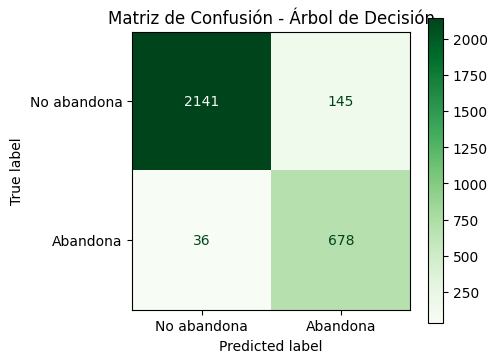

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_dt,
    display_labels=['No abandona', 'Abandona'],
    cmap='Greens', ax=ax
)
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.tight_layout()
plt.show()